In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'D:\predictive-maintenance-sme')
os.makedirs('assets', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load simulated data — has RUL labels per cycle per machine
df = pd.read_csv('data/simulated/sensor_simulation.csv')

print("Simulated data shape:", df.shape)
print("Columns:", df.columns.tolist())
print(f"Machines: {sorted(df['machine_id'].unique())}")
print(f"Cycles per machine: {df.groupby('machine_id')['cycle'].count().values}")
print(f"\nRUL stats:")
print(f"  Min : {df['rul'].min()}")
print(f"  Max : {df['rul'].max()}")
print(f"  Mean: {df['rul'].mean():.1f}")
print(f"\nFailure rate: {df['failure'].mean():.2%}")

Simulated data shape: (25000, 8)
Columns: ['machine_id', 'cycle', 'temperature', 'vibration', 'pressure', 'rotational_speed', 'failure', 'rul']
Machines: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Cycles per machine: [5000 5000 5000 5000 5000]

RUL stats:
  Min : 0
  Max : 4600
  Mean: 1772.4

Failure rate: 16.00%


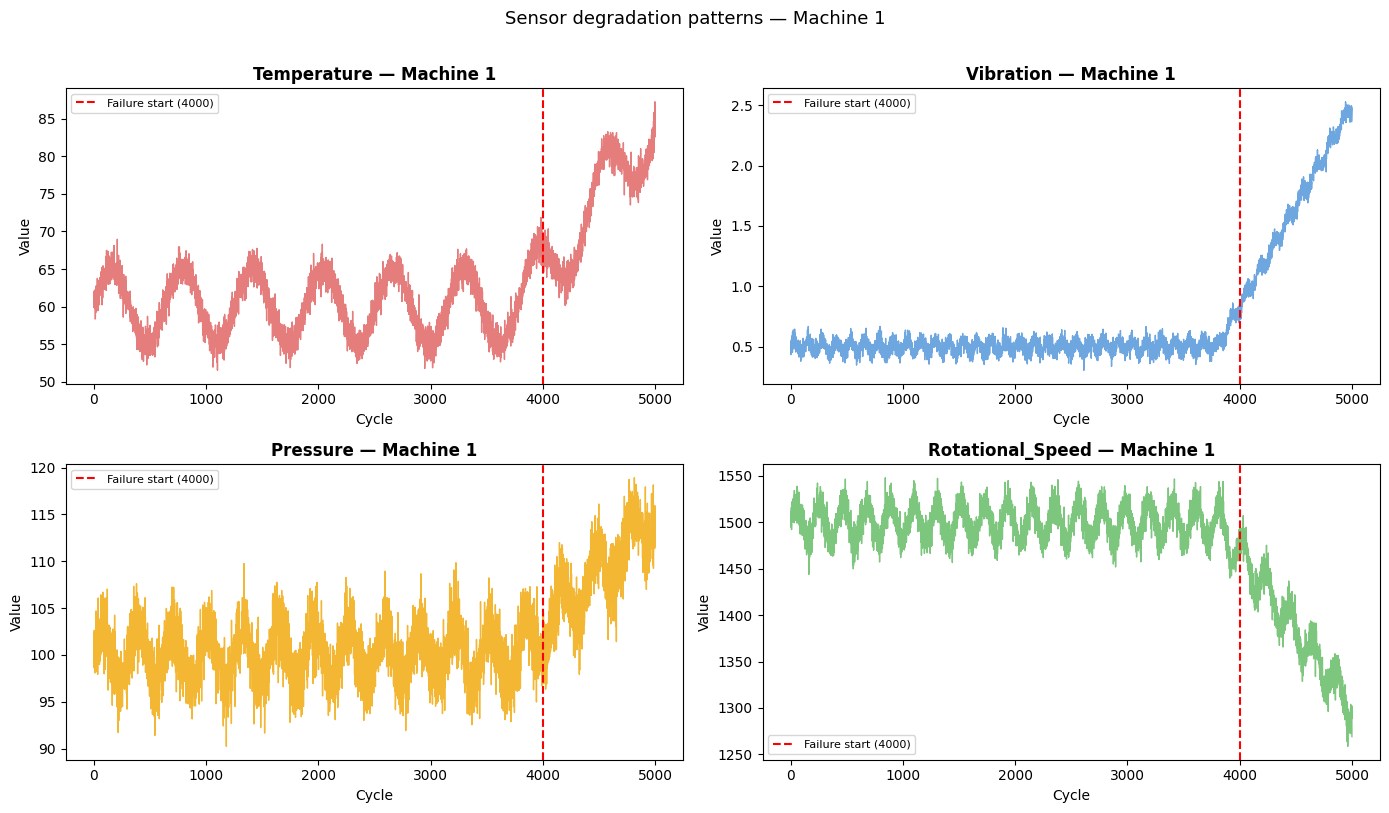

Saved: assets/sensor_degradation.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

sensors    = ['temperature', 'vibration', 'pressure', 'rotational_speed']
colors     = ['#e05c5c', '#4a90d9', '#f0a500', '#5cb85c']
machine_df = df[df['machine_id'] == 1]

for i, (sensor, color) in enumerate(zip(sensors, colors)):
    axes[i].plot(machine_df['cycle'], machine_df[sensor],
                 color=color, linewidth=1, alpha=0.8)

    # Mark failure start
    failure_start = machine_df[machine_df['failure'] == 1]['cycle'].min()
    if not pd.isna(failure_start):
        axes[i].axvline(failure_start, color='red',
                        linestyle='--', linewidth=1.5,
                        label=f'Failure start ({int(failure_start)})')

    axes[i].set_title(f'{sensor.title()} — Machine 1',
                      fontweight='bold')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor degradation patterns — Machine 1',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('assets/sensor_degradation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/sensor_degradation.png")

In [3]:
from sklearn.preprocessing import MinMaxScaler

SENSORS = ['temperature', 'vibration', 'pressure', 'rotational_speed']
SEQ_LEN = 30
RUL_CAP = 200  # cap RUL — standard practice in predictive maintenance

# Scale sensors
scaler_lstm = MinMaxScaler()
df[SENSORS]  = scaler_lstm.fit_transform(df[SENSORS])

# Cap RUL
df['rul_capped'] = np.minimum(df['rul'], RUL_CAP)

with open('models/lstm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_lstm, f)

print(f"Sensors scaled with MinMaxScaler")
print(f"RUL capped at {RUL_CAP} cycles")
print(f"Saved: models/lstm_scaler.pkl")
print(f"\nScaled sensor ranges:")
for s in SENSORS:
    print(f"  {s}: {df[s].min():.3f} — {df[s].max():.3f}")

Sensors scaled with MinMaxScaler
RUL capped at 200 cycles
Saved: models/lstm_scaler.pkl

Scaled sensor ranges:
  temperature: 0.000 — 1.000
  vibration: 0.000 — 1.000
  pressure: 0.000 — 1.000
  rotational_speed: 0.000 — 1.000


In [4]:
def make_sequences(df, seq_len=30, sensor_cols=SENSORS):
    """
    Build sliding window sequences per machine.
    Each sequence = seq_len cycles of sensor readings.
    Target = RUL at the end of the sequence.
    """
    X, y = [], []
    for machine_id in sorted(df['machine_id'].unique()):
        mdf = df[df['machine_id'] == machine_id].reset_index(drop=True)
        arr = mdf[sensor_cols].values
        rul = mdf['rul_capped'].values

        for i in range(seq_len, len(arr)):
            X.append(arr[i-seq_len:i])
            y.append(rul[i])

    return np.array(X), np.array(y)

X, y = make_sequences(df, SEQ_LEN)

print(f"Sequence shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"  X: (samples, timesteps, features)")
print(f"  y: (samples,) — RUL value per sequence")

# Train/test split — 80/20
split   = int(len(X) * 0.80)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

print(f"\nTrain sequences: {X_train.shape}")
print(f"Test sequences : {X_test.shape}")
print(f"\nRUL target stats:")
print(f"  Train mean: {y_train.mean():.1f}")
print(f"  Test mean : {y_test.mean():.1f}")

Sequence shape : (24850, 30, 4)
Target shape   : (24850,)
  X: (samples, timesteps, features)
  y: (samples,) — RUL value per sequence

Train sequences: (19880, 30, 4)
Test sequences : (4970, 30, 4)

RUL target stats:
  Train mean: 159.8
  Test mean : 179.9


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Input(shape=(SEQ_LEN, len(SENSORS))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mse']
)

model.summary()

TensorFlow version: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┓
┃ Layer       ┃ Output  ┃ Par… ┃
┃ (type)      ┃ Shape   ┃    # ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━┩
│ lstm (LSTM) │ (None,  │ 17,… │
│             │ 30, 64) │      │
├─────────────┼─────────┼──────┤
│ dropout     │ (None,  │    0 │
│ (Dropout)   │ 30, 64) │      │
├─────────────┼─────────┼──────┤
│ lstm_1      │ (None,  │ 12,… │
│ (LSTM)      │ 32)     │      │
├─────────────┼─────────┼──────┤
│ dropout_1   │ (None,  │    0 │
│ (Dropout)   │ 32)     │      │
├─────────────┼─────────┼──────┤
│ dense       │ (None,  │  528 │
│ (Dense)     │ 16)     │      │
├─────────────┼─────────┼──────┤
│ dense_1     │ (None,  │   17 │
│ (Dense)     │ 1)      │      │
└─────────────┴─────────┴──────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("Training LSTM...")
print("Early stopping patience: 10 epochs\n")

callbacks = [
    EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_loss',
        verbose=1
    ),
    ModelCheckpoint(
        'models/lstm_rul.keras',
        save_best_only=True,
        monitor='val_loss',
        verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining complete.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Epochs run   : {len(history.history['loss'])}")

Training LSTM...
Early stopping patience: 10 epochs

Epoch 1/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - loss: 130.1503 - mse: 20866.8691 - val_loss: 65.1447 - val_mse: 6062.2812
Epoch 2/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 31.5947 - mse: 2368.0444 - val_loss: 20.1692 - val_mse: 3226.9929
Epoch 3/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 15.8039 - mse: 946.2487 - val_loss: 6.1215 - val_mse: 520.7065
Epoch 4/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 13.0006 - mse: 386.9725 - val_loss: 6.0360 - val_mse: 458.8750
Epoch 5/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 12.7028 - mse: 375.6205 - val_loss: 5.6975 - val_mse: 452.3356
Epoch 6/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 12.6916 - mse: 374.1751 - val_loss: 5.6934 - val_mse: 444.6889
Epoch 7/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 12.7702 - mse: 378.6228 - val_loss: 5.8604 - val_mse: 429.2455
Epoch 8/80
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 12

In [7]:
y_pred = model.predict(X_test).flatten()

mae  = float(np.mean(np.abs(y_pred - y_test)))
rmse = float(np.sqrt(np.mean((y_pred - y_test) ** 2)))
r2   = float(1 - np.sum((y_test - y_pred)**2) /
             np.sum((y_test - np.mean(y_test))**2))

print("=== LSTM RUL Predictor — Test Results ===\n")
print(f"MAE  : {mae:.2f} cycles")
print(f"RMSE : {rmse:.2f} cycles")
print(f"R²   : {r2:.4f}")
print(f"\nInterpretation:")
print(f"  On average the model is off by {mae:.1f} cycles")
print(f"  RUL is capped at {RUL_CAP} — so {mae:.1f} cycles = "
      f"{mae/RUL_CAP*100:.1f}% error")

156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
=== LSTM RUL Predictor — Test Results ===

MAE  : 4.16 cycles
RMSE : 12.73 cycles
R²   : 0.9516

Interpretation:
  On average the model is off by 4.2 cycles
  RUL is capped at 200 — so 4.2 cycles = 2.1% error


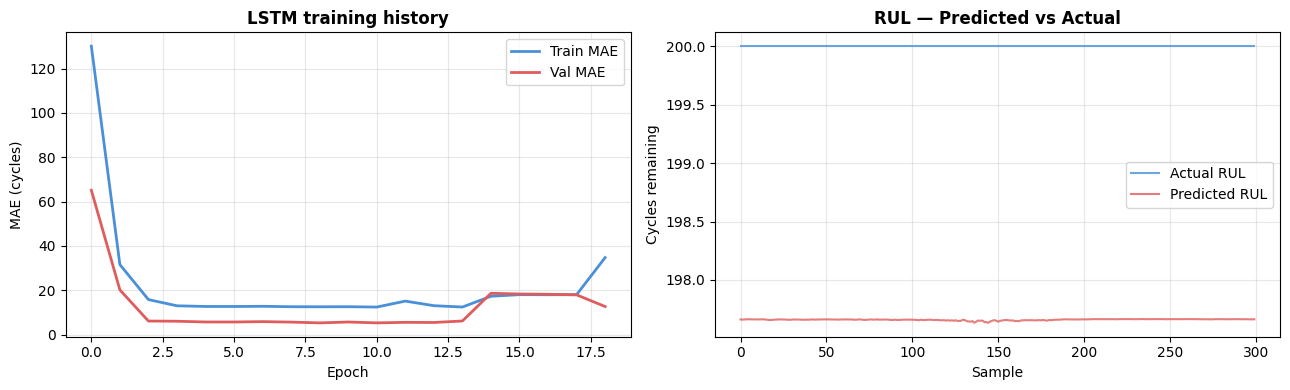

Saved: assets/lstm_training.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(history.history['loss'],
             label='Train MAE', color='#4a90d9', linewidth=2)
axes[0].plot(history.history['val_loss'],
             label='Val MAE', color='#e05c5c', linewidth=2)
axes[0].set_title('LSTM training history', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (cycles)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted vs actual
sample_n = min(300, len(y_test))
axes[1].plot(y_test[:sample_n],
             label='Actual RUL', color='#4a90d9',
             linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred[:sample_n],
             label='Predicted RUL', color='#e05c5c',
             linewidth=1.5, alpha=0.8)
axes[1].set_title('RUL — Predicted vs Actual', fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Cycles remaining')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/lstm_training.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/lstm_training.png")

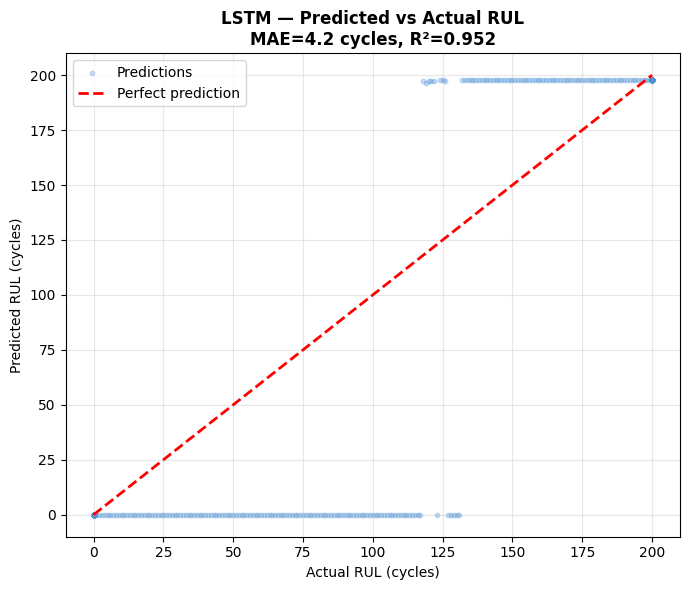

Saved: assets/lstm_scatter.png


In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10,
            color='#4a90d9', label='Predictions')
plt.plot([0, RUL_CAP], [0, RUL_CAP],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'LSTM — Predicted vs Actual RUL\n'
          f'MAE={mae:.1f} cycles, R²={r2:.3f}',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/lstm_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/lstm_scatter.png")

In [10]:
# Model already saved by ModelCheckpoint
# Save metrics and config

lstm_metrics = {
    'model':        'LSTM',
    'mae':          round(mae, 2),
    'rmse':         round(rmse, 2),
    'r2':           round(r2, 4),
    'rul_cap':      RUL_CAP,
    'seq_len':      SEQ_LEN,
    'sensors_used': SENSORS,
    'epochs_run':   len(history.history['loss']),
    'best_val_mae': round(min(history.history['val_loss']), 4)
}

with open('models/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=2)

print("=== LSTM Metrics saved ===")
for k, v in lstm_metrics.items():
    print(f"  {k:<20}: {v}")

=== LSTM Metrics saved ===
  model               : LSTM
  mae                 : 4.16
  rmse                : 12.73
  r2                  : 0.9516
  rul_cap             : 200
  seq_len             : 30
  sensors_used        : ['temperature', 'vibration', 'pressure', 'rotational_speed']
  epochs_run          : 19
  best_val_mae        : 5.2897


In [11]:
files = [
    'models/lstm_rul.keras',
    'models/lstm_scaler.pkl',
    'models/lstm_metrics.json',
    'assets/sensor_degradation.png',
    'assets/lstm_training.png',
    'assets/lstm_scatter.png'
]

print("=== File verification ===")
all_good = True
for f in files:
    status = "OK     " if os.path.exists(f) else "MISSING"
    print(f"  {status} {f}")
    if "MISSING" in status:
        all_good = False

if all_good:
    print("\nAll files present. Day 7 complete.")
else:
    print("\nSome files missing. Re-run relevant cells.")

=== File verification ===
  OK      models/lstm_rul.keras
  OK      models/lstm_scaler.pkl
  OK      models/lstm_metrics.json
  OK      assets/sensor_degradation.png
  OK      assets/lstm_training.png
  OK      assets/lstm_scatter.png

All files present. Day 7 complete.
